In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from pmdarima import auto_arima

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import joblib

from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb
from lightgbm import LGBMRegressor

# Data Loading

In [2]:
file_path = '../data/pangoly.csv'
raw = pd.read_csv(file_path)

len(raw)

239295

In [3]:
raw.columns

Index(['date', 'avg', 'min', 'max', 'category', 'product'], dtype='object')

In [4]:
data = raw.copy()

In [5]:
data['date'] = pd.to_datetime(data['date'])

In [6]:
data.columns

Index(['date', 'avg', 'min', 'max', 'category', 'product'], dtype='object')

In [7]:
cats = ["PROCESSORS", "GRAPHICS CARDS", "MEMORY", "SOLID STATE DRIVES"]

In [8]:
select = data[data['category'].isin(cats)]
len(select)

102247

# ARIMA

In [9]:
dfs = {}

for cat in select['category'].unique():
    dfs[cat] = {}

    cat_df = select[select['category'] == cat]
    for prod in cat_df['product'].unique():
        df = cat_df[cat_df['product'] == prod].copy()
        # df = df.set_index('date')
        # df.index = df.index.normalize()
        # df = df.sort_index()
        df = df.sort_values(by=['date'])
        dfs[cat][prod] = df
        # print(df.columns)

In [10]:
dfs

{'PROCESSORS': {'AM3+ Vishera':             date     avg     min     max    category       product
  18666 2021-08-25  283.67  129.99  391.02  PROCESSORS  AM3+ Vishera
  18667 2021-08-26  283.67  129.99  391.02  PROCESSORS  AM3+ Vishera
  18668 2021-08-27  283.67  129.99  391.02  PROCESSORS  AM3+ Vishera
  18669 2021-08-28  283.67  129.99  391.02  PROCESSORS  AM3+ Vishera
  18670 2021-08-29  283.67  129.99  391.02  PROCESSORS  AM3+ Vishera
  ...          ...     ...     ...     ...         ...           ...
  20488 2026-08-21  169.99  169.99  169.99  PROCESSORS  AM3+ Vishera
  20489 2026-08-22  169.99  169.99  169.99  PROCESSORS  AM3+ Vishera
  20490 2026-08-23  169.99  169.99  169.99  PROCESSORS  AM3+ Vishera
  20491 2026-08-24  169.99  169.99  169.99  PROCESSORS  AM3+ Vishera
  20492 2026-08-25  169.99  169.99  169.99  PROCESSORS  AM3+ Vishera
  
  [1827 rows x 6 columns],
  'AM4 Cezanne':             date     avg     min     max    category      product
  20493 2021-08-25  312.00  2

In [11]:
split = {}
for cat, cat_data in dfs.items():
    split[cat] = {}

    for prod, prod_df in cat_data.items():
        split[cat][prod] = {}
        len_train = round(len(prod_df) * 0.9)

        df_train = prod_df[:len_train]
        df_test = prod_df[len_train:]

        split[cat][prod]['train'] = df_train
        split[cat][prod]['test'] = df_test

## Training

In [12]:
models = {}

for cat, prod_dfs in split.items():
    models[cat] = {}
    for prod, dataset in prod_dfs.items():
        model = auto_arima(dataset['train']['avg'], seasonal=False, stepwise=True)
        models[cat][prod] = model

In [13]:
joblib.dump(models, 'arima.joblib', compress=3)

['arima.joblib']

## Errors

In [14]:
arima_preds = {}
for cat, prod_dfs in split.items():
    arima_preds[cat] = {}
    for prod, dataset in prod_dfs.items():
        test_set = dataset['test']
        model = models[cat][prod]
        arima_preds[cat][prod] = model.predict(n_periods=len(test_set))

/opt/anaconda3/envs/h8_env/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/h8_env/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/h8_env/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/h8_env/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt

In [15]:
arima_errors = {'category': [], 'product': [], 'mae': [], 'rmse': [], 'step': []}
for cat, cat_data in arima_preds.items():
    for prod, pred in cat_data.items():
        y_test = split[cat][prod]['test']['avg']
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        arima_errors['category'].append(cat)
        arima_errors['product'].append(prod)
        arima_errors['mae'].append(mae)
        arima_errors['rmse'].append(rmse)
        arima_errors['step'].append(len(y_test))

arima_errors_df = pd.DataFrame(arima_errors)
arima_errors_df.head()

,category,product,mae,rmse,step
0,PROCESSORS,AM3+ Vishera,0.000035,0.000035,183
1,PROCESSORS,AM4 Cezanne,4.759571,5.595006,183
2,PROCESSORS,AM4 Matisse,75.074026,76.675186,183
3,PROCESSORS,AM4 Pinnacle Ridge,62.637984,72.966083,183
4,PROCESSORS,AM4 Summit Ridge,61.365000,63.632813,183


In [16]:
arima_errors_df[arima_errors_df['category']=='GRAPHICS CARDS']

,category,product,mae,rmse,step
31,GRAPHICS CARDS,GeForce RTX 3060,22.342087,28.690415,183
32,GRAPHICS CARDS,GeForce RTX 3060 Ti,25.982164,30.015788,183
33,GRAPHICS CARDS,GeForce RTX 4070 Ti SUPER,63.686915,108.395585,94
34,GRAPHICS CARDS,GeForce RTX 4080,106.538396,126.666204,138
35,GRAPHICS CARDS,GeForce RTX 4080 SUPER,62.430532,177.073262,94
36,GRAPHICS CARDS,GeForce RTX 4090,233.712624,372.274366,141
37,GRAPHICS CARDS,GeForce RTX 5050,50.462131,65.915288,42
38,GRAPHICS CARDS,GeForce RTX 5060,49.788238,66.818647,46
39,GRAPHICS CARDS,GeForce RTX 5060 Ti,93.452198,133.279858,50
40,GRAPHICS CARDS,GeForce RTX 5060 Ti 8GB,44.909722,60.937562,50


# LightGBM

In [17]:
def prepare_df(raw: pd.DataFrame, lags: list = [1], rolling: list = []) -> pd.DataFrame:
    df = raw.copy()
    df = raw[['avg', 'date', 'product', 'category']].copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by='date', ascending=True)

    for col in ['product', 'category']:
        df[col] = df[col].astype('category')

    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    
    for lag in lags:
        df[f'lag_{lag}d'] = df['avg'].shift(lag)

    for window in rolling:
        df[f'mean_{window}d'] = df['avg'].shift(1).rolling(window=window).mean()
        df[f'max_{window}d'] = df['avg'].shift(1).rolling(window=window).max()
        df[f'min_{window}d'] = df['avg'].shift(1).rolling(window=window).min()
        df[f'std_{window}d'] = df['avg'].shift(1).rolling(window=window).std()

    df['pct_change'] = ((df['avg'] - df['lag_1d'])/df['lag_1d'])*100

    df = df.dropna().reset_index(drop=True)

    return df

In [30]:
lags = [1,2,3,7,14,30]
rolling = [3, 7, 30]

train_dfs = []
for cat, cat_data in split.items():
    for prod, dataset in cat_data.items():
        train_df = prepare_df(dataset['train'], lags=lags, rolling=rolling)
        train_dfs.append(train_df)

lgb_train_df = pd.concat(train_dfs)

In [31]:
lgb_train_df['product'] = lgb_train_df['product'].astype('category')
lgb_train_df['category'] = lgb_train_df['category'].astype('category')

In [67]:
lgb_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=15, min_child_samples=30)

In [ ]:
y_train = lgb_train_df['pct_change']
X_train = lgb_train_df.drop(columns=['pct_change', 'avg', 'date'])

In [68]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4729
[LightGBM] [Info] Number of data points in the train set: 89879, number of used features: 26
[LightGBM] [Info] Start training from score 0.137908


LGBMRegressor(max_depth=15, min_child_samples=30)

In [25]:
def predict(steps: int, product: str, df: pd.DataFrame):
    df_prod_original = df[df['product'] == product]

    df_prod = df_prod_original.copy()
    df_prod = df_prod.sort_values(by=['date'], ascending=True)

    latest_known_date = df_prod['date'].max()
    cat = df_prod['category'][0]

    preds = []
    for _ in range(steps):
        new_date = latest_known_date + dt.timedelta(days=1)
        data = {
            'date': [new_date],
            'product': [product],
            'category': [cat]
        }
        current_df = pd.DataFrame(data)

        for col in ['product', 'category']:
            current_df[col] = current_df[col].astype('category')
        
        current_df['day_of_week'] = current_df['date'].dt.dayofweek
        current_df['day_of_month'] = current_df['date'].dt.day
        current_df['month'] = current_df['date'].dt.month
        current_df['year'] = current_df['date'].dt.year
        current_df['is_weekend'] = current_df['day_of_week'].isin([5,6]).astype(int)
        current_df['is_month_end'] = current_df['date'].dt.is_month_end.astype(int)

        for lag in lags:
            current_df[f'lag_{lag}d'] = df_prod['avg'].iloc[-lag]

        for window in rolling:
            current_df[f'mean_{window}d'] = df_prod['avg'].iloc[-window:].mean()
            current_df[f'max_{window}d'] = df_prod['avg'].iloc[-window:].max()
            current_df[f'min_{window}d'] = df_prod['avg'].iloc[-window:].min()
            current_df[f'std_{window}d'] = df_prod['avg'].iloc[-window:].std()

        X = current_df.drop(columns=['date'])
        pred = lgb_model.predict(X)

        current_df['pct_change'] = pred
        current_df['avg'] = current_df['lag_1d'] * (1 + (pred/100))
        df_prod = pd.concat([df_prod, current_df])
        latest_known_date = df_prod['date'].max()
        preds.append(current_df)

    df_prod_original['is_pred'] = False
    df_preds = pd.concat(preds)
    df_preds['is_pred'] = True
    return pd.concat([df_prod_original, df_preds])

In [29]:
lgb_train_df.columns

Index(['avg', 'product', 'category', 'day_of_week', 'day_of_month', 'month',
       'year', 'is_weekend', 'is_month_end', 'lag_1d', 'lag_2d', 'lag_3d',
       'lag_7d', 'lag_14d', 'lag_30d', 'mean_3d', 'max_3d', 'min_3d', 'std_3d',
       'mean_7d', 'max_7d', 'min_7d', 'std_7d', 'mean_30d', 'max_30d',
       'min_30d', 'std_30d', 'pct_change'],
      dtype='object')

In [69]:
lgb_preds = {}
for cat, prod_dfs in split.items():
    lgb_preds[cat] = {}
    for prod, dataset in prod_dfs.items():
        test_set = dataset['test']
        steps = len(test_set)
        lgb_preds[cat][prod] = predict(steps, prod, df=lgb_train_df)

AM3+ Vishera 183
AM4 Cezanne 183
AM4 Matisse 183
AM4 Pinnacle Ridge 183
AM4 Summit Ridge 183
AM4 Vermeer 183
AM5 Granite Ridge 74
AM5 Phoenix 95
AM5 Raphael 143
LGA1150 Haswell 183
LGA1151 Coffee Lake 183
LGA1151 Kaby Lake 183
LGA1151 Skylake 183
LGA1200 Comet Lake 183
LGA1200 Rocket Lake 183
LGA1700 Alder Lake 176
LGA1700 Raptor Lake 142
LGA1851 Arrow Lake 68
LGA2066 Skylake X 183
sTR5 Storm Peak 100
8GB DDR4 183
8GB DDR5 157
16GB DDR4 183
16GB DDR5 173
32GB DDR4 183
32GB DDR5 157
48GB DDR5 120
64GB DDR4 183
64GB DDR5 174
96GB DDR5 120
128GB DDR5 120
GeForce RTX 3060 183
GeForce RTX 3060 Ti 183
GeForce RTX 4070 Ti SUPER 94
GeForce RTX 4080 138
GeForce RTX 4080 SUPER 94
GeForce RTX 4090 141
GeForce RTX 5050 42
GeForce RTX 5060 46
GeForce RTX 5060 Ti 50
GeForce RTX 5060 Ti 8GB 50
GeForce RTX 5070 57
GeForce RTX 5070 Ti 56
GeForce RTX 5080 58
GeForce RTX 5090 59
Radeon RX 7600 119
Radeon RX 7900 XTX 135
Radeon RX 9060 XT 45
Radeon RX 9070 54
Radeon RX 9070 XT 54
120GB SATA 6 Gb/s 183
128

In [33]:
joblib.dump(lgb_model, 'lgbm.joblib', compress=3)

['lgbm.joblib']

In [70]:
lgb_errors = {'category': [], 'product': [], 'mae': [], 'rmse': [], 'step': []}
for cat, cat_data in lgb_preds.items():
    for prod, pred in cat_data.items():
        y_test = split[cat][prod]['test']['avg']
        y_pred = pred[pred['is_pred'] == True]['avg']
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        lgb_errors['category'].append(cat)
        lgb_errors['product'].append(prod)
        lgb_errors['mae'].append(mae)
        lgb_errors['rmse'].append(rmse)
        lgb_errors['step'].append(len(y_test))

lgb_errors_df = pd.DataFrame(lgb_errors)
lgb_errors_df.head()

,category,product,mae,rmse,step
0,PROCESSORS,AM3+ Vishera,64.265187,74.575499,183
1,PROCESSORS,AM4 Cezanne,20.873128,21.968621,183
2,PROCESSORS,AM4 Matisse,145.157980,153.856799,183
3,PROCESSORS,AM4 Pinnacle Ridge,29.844571,37.626347,183
4,PROCESSORS,AM4 Summit Ridge,42.496253,44.123062,183


# Compare

In [71]:
len(lgb_errors_df)

71

In [72]:
arima_errors_df = arima_errors_df.drop(columns=['step'])
lgb_errors_df = lgb_errors_df.drop(columns=['step'])

KeyError: "['step'] not found in axis"

In [73]:
comparison = arima_errors_df.merge(lgb_errors_df, on=['category', 'product'], suffixes=['_arima', '_lgb'])

In [74]:
comparison.head()

,category,product,mae_arima,rmse_arima,mae_lgb,rmse_lgb,step
0,PROCESSORS,AM3+ Vishera,0.000035,0.000035,64.265187,74.575499,183
1,PROCESSORS,AM4 Cezanne,4.759571,5.595006,20.873128,21.968621,183
2,PROCESSORS,AM4 Matisse,75.074026,76.675186,145.157980,153.856799,183
3,PROCESSORS,AM4 Pinnacle Ridge,62.637984,72.966083,29.844571,37.626347,183
4,PROCESSORS,AM4 Summit Ridge,61.365000,63.632813,42.496253,44.123062,183


In [75]:
comparison['mae_diff'] = comparison['mae_arima'] - comparison['mae_lgb']
comparison['rmse_diff'] = comparison['rmse_arima'] - comparison['rmse_lgb']

comparison['better_model'] = np.where(comparison['mae_diff'] > 0, 'lgb', 'arima')

In [76]:
comparison.head(5)

,category,product,mae_arima,rmse_arima,mae_lgb,rmse_lgb,step,mae_diff,rmse_diff,better_model
0,PROCESSORS,AM3+ Vishera,0.000035,0.000035,64.265187,74.575499,183,-64.265153,-74.575464,arima
1,PROCESSORS,AM4 Cezanne,4.759571,5.595006,20.873128,21.968621,183,-16.113557,-16.373615,arima
2,PROCESSORS,AM4 Matisse,75.074026,76.675186,145.157980,153.856799,183,-70.083954,-77.181613,arima
3,PROCESSORS,AM4 Pinnacle Ridge,62.637984,72.966083,29.844571,37.626347,183,32.793412,35.339736,lgb
4,PROCESSORS,AM4 Summit Ridge,61.365000,63.632813,42.496253,44.123062,183,18.868747,19.509751,lgb


In [77]:
comparison['better_model'].value_counts()

better_model
arima    36
lgb      35
Name: count, dtype: int64

In [78]:
comparison.groupby('category')[['mae_arima', 'mae_lgb']].mean()

,mae_arima,mae_lgb
category,,
GRAPHICS CARDS,63.783365,63.765690
MEMORY,104.541852,137.381595
PROCESSORS,66.040460,91.597089
SOLID STATE DRIVES,67.494514,73.215029


In [81]:
comparison.groupby('category')[['mae_diff']].agg(['mean', 'median'])

mae_diff           
                         mean     median
category                                
GRAPHICS CARDS       0.017674   2.482934
MEMORY             -32.839743 -15.815022
PROCESSORS         -25.556629 -10.514715
SOLID STATE DRIVES  -5.720515  -2.382445

In [82]:
print('ARIMA  -> MAE:', comparison['mae_arima'].mean(), 'RMSE:', comparison['rmse_arima'].mean())
print('LightGBM -> MAE:', comparison['mae_lgb'].mean(), 'RMSE:', comparison['rmse_lgb'].mean())

ARIMA  -> MAE: 71.83152524960285 RMSE: 91.67601759657262
LightGBM -> MAE: 85.80567695340221 RMSE: 105.53700954318441


In [80]:
comparison[comparison['category'] == 'MEMORY'].sort_values('mae_diff')

,category,product,mae_arima,rmse_arima,mae_lgb,rmse_lgb,step,mae_diff,rmse_diff,better_model
30,MEMORY,128GB DDR5,497.934732,653.679064,837.565570,919.479283,120,-339.630839,-265.800219,arima
28,MEMORY,64GB DDR5,125.957290,146.566026,185.576277,222.382169,174,-59.618987,-75.816143,arima
23,MEMORY,16GB DDR5,16.079378,19.161660,50.667615,61.222440,173,-34.588237,-42.060780,arima
24,MEMORY,32GB DDR4,75.892204,91.782359,109.736725,135.442486,183,-33.844521,-43.660127,arima
25,MEMORY,32GB DDR5,38.444249,43.301624,57.707212,65.335883,157,-19.262963,-22.034258,arima
22,MEMORY,16GB DDR4,30.064491,37.601550,45.879513,56.152395,183,-15.815022,-18.550844,arima
29,MEMORY,96GB DDR5,74.836006,88.751204,71.912692,85.976539,120,2.923315,2.774665,lgb
21,MEMORY,8GB DDR5,87.394136,102.069503,78.636179,93.537052,157,8.757958,8.532451,lgb
20,MEMORY,8GB DDR4,16.979657,21.280392,3.493448,3.758027,183,13.486209,17.522364,lgb
26,MEMORY,48GB DDR5,90.650400,122.329465,37.190305,47.614622,120,53.460095,74.714843,lgb


In [83]:
comparison[comparison['category'] == 'PROCESSORS'].sort_values('mae_diff')

,category,product,mae_arima,rmse_arima,mae_lgb,rmse_lgb,step,mae_diff,rmse_diff,better_model
19,PROCESSORS,sTR5 Storm Peak,844.074129,1000.463275,992.260842,1158.127366,100,-148.186713,-157.664090,arima
18,PROCESSORS,LGA2066 Skylake X,37.972745,47.153077,162.552661,183.255652,183,-124.579916,-136.102576,arima
2,PROCESSORS,AM4 Matisse,75.074026,76.675186,145.157980,153.856799,183,-70.083954,-77.181613,arima
0,PROCESSORS,AM3+ Vishera,0.000035,0.000035,64.265187,74.575499,183,-64.265153,-74.575464,arima
14,PROCESSORS,LGA1200 Rocket Lake,22.769655,27.840731,62.044851,79.790751,183,-39.275196,-51.950020,arima
8,PROCESSORS,AM5 Raphael,33.466551,35.261869,65.778110,69.265533,143,-32.311560,-34.003664,arima
12,PROCESSORS,LGA1151 Skylake,22.671639,26.060938,54.066914,62.455446,183,-31.395275,-36.394509,arima
11,PROCESSORS,LGA1151 Kaby Lake,7.006613,11.901322,26.807273,31.273302,183,-19.800660,-19.371980,arima
1,PROCESSORS,AM4 Cezanne,4.759571,5.595006,20.873128,21.968621,183,-16.113557,-16.373615,arima
9,PROCESSORS,LGA1150 Haswell,7.731199,8.915810,19.249543,21.067337,183,-11.518344,-12.151527,arima


In [84]:
comparison[comparison['category'] == 'GRAPHICS CARDS'].sort_values('mae_diff')

,category,product,mae_arima,rmse_arima,mae_lgb,rmse_lgb,step,mae_diff,rmse_diff,better_model
34,GRAPHICS CARDS,GeForce RTX 4080,106.538396,126.666204,146.670688,170.340295,138,-40.132293,-43.674092,arima
32,GRAPHICS CARDS,GeForce RTX 3060 Ti,25.982164,30.015788,36.284132,41.092858,183,-10.301967,-11.077069,arima
35,GRAPHICS CARDS,GeForce RTX 4080 SUPER,62.430532,177.073262,68.553980,165.308040,94,-6.123448,11.765222,arima
49,GRAPHICS CARDS,Radeon RX 9070 XT,5.089997,6.777532,5.572174,7.203654,54,-0.482177,-0.426122,arima
45,GRAPHICS CARDS,Radeon RX 7600,12.684034,20.100504,11.600366,16.989262,119,1.083668,3.111242,lgb
40,GRAPHICS CARDS,GeForce RTX 5060 Ti 8GB,44.909722,60.937562,43.613038,59.070837,50,1.296684,1.866725,lgb
31,GRAPHICS CARDS,GeForce RTX 3060,22.342087,28.690415,20.831855,27.695830,183,1.510232,0.994585,lgb
39,GRAPHICS CARDS,GeForce RTX 5060 Ti,93.452198,133.279858,91.304334,130.533013,50,2.147865,2.746845,lgb
38,GRAPHICS CARDS,GeForce RTX 5060,49.788238,66.818647,47.362525,63.704623,46,2.425713,3.114024,lgb
48,GRAPHICS CARDS,Radeon RX 9070,16.397760,20.640305,13.914827,17.592280,54,2.482934,3.048024,lgb


In [85]:
comparison[comparison['category'] == 'SOLID STATE DRIVES'].sort_values('mae_diff')

,category,product,mae_arima,rmse_arima,mae_lgb,rmse_lgb,step,mae_diff,rmse_diff,better_model
70,SOLID STATE DRIVES,4TB PCIe Gen5 x4,20.702723,25.131699,170.379034,198.203191,114,-149.676311,-173.071492,arima
69,SOLID STATE DRIVES,4TB PCIe Gen4 x4,226.754322,265.761759,300.005884,366.708651,183,-73.251561,-100.946892,arima
68,SOLID STATE DRIVES,2TB SATA 6 Gb/s,25.783330,34.790645,95.639239,132.908399,183,-69.855909,-98.117754,arima
63,SOLID STATE DRIVES,1TB PCIe Gen5 x4,4.962829,6.390660,38.834127,44.518996,121,-33.871298,-38.128335,arima
67,SOLID STATE DRIVES,2TB PCIe Gen5 x4,114.559884,137.639110,146.994942,168.125357,121,-32.435058,-30.486247,arima
66,SOLID STATE DRIVES,2TB PCIe Gen4 x4,113.322543,135.118694,141.721820,178.072416,183,-28.399277,-42.953722,arima
56,SOLID STATE DRIVES,480GB SATA 6 Gb/s,33.423077,60.969564,50.095387,61.231609,183,-16.672310,-0.262045,arima
65,SOLID STATE DRIVES,2TB PCIe Gen3 x4,137.867808,158.701905,149.796374,175.246451,183,-11.928566,-16.544547,arima
57,SOLID STATE DRIVES,500GB PCIe Gen3 x4,52.358047,69.998466,60.265505,80.470820,183,-7.907459,-10.472354,arima
54,SOLID STATE DRIVES,256GB PCIe Gen3 x4,2.333054,3.213003,7.215093,7.953369,183,-4.882039,-4.740366,arima


In [56]:
def plot_time_series(df1: pd.DataFrame, col: str, df2: pd.DataFrame = None, df1_label: str = 'data 1', df2_label: str = 'data 2', x_col: str = None):
    fig, ax = plt.subplots(figsize=(12, 7))

    x_1 = df1.index if x_col is None else df1[x_col]
    ax.plot(x_1, df1[col], color='blue', label=df1_label)

    if df2 is not None:
        x_2 = df2.index if x_col is None else df2[x_col]
        ax.plot(x_2, df2[col], color='orange', label=df2_label)

    plt.ylabel('Avg Price (USD)')
    plt.xlabel('Date')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [64]:
def plot_data_split(cat, prod):
    data_split = split[cat][prod]
    plot_time_series(data_split['train'], 'avg', df2=data_split['test'], df1_label='train', df2_label='test', x_col='date')

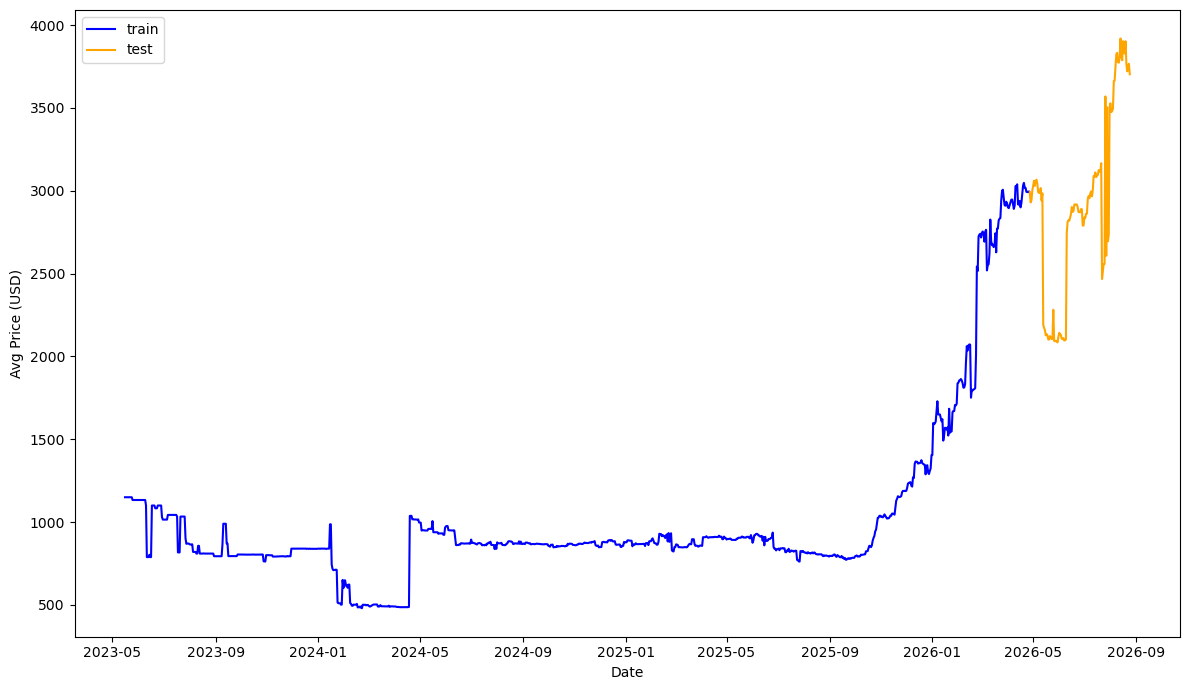

In [65]:
plot_data_split('MEMORY', '128GB DDR5')

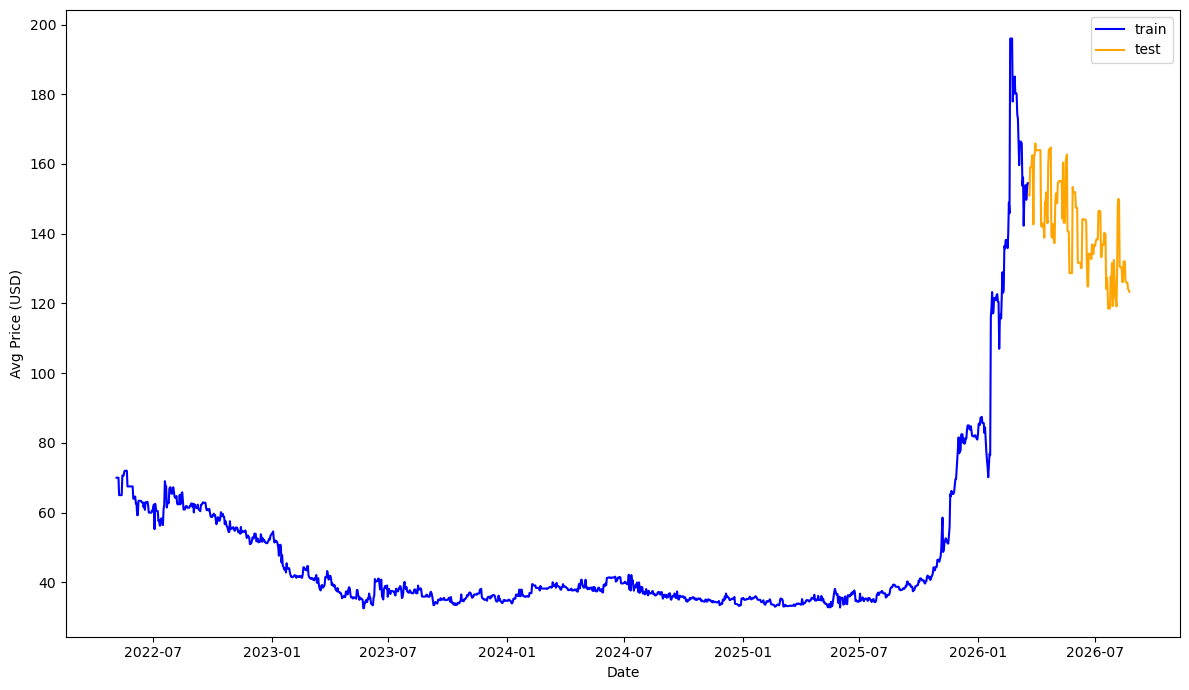

In [66]:
plot_data_split('MEMORY', '8GB DDR5')

# Conclusion

1. ARIMA memiliki error yang lebih kecil dibandingkan LightGBM.
2. Error terbesar